## Run initially to download data otherwise ignore

In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/superconductivty-data-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1


## Main code

In [4]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics


# maximize display of dataframe columns
pd.set_option('display.max_columns', None)

In [5]:


file = r"C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1\train.csv"

with open(file, 'r') as f:
    reader = csv.reader(f)
    labels = next(reader)
    data = [row for row in reader]

df = pd.DataFrame(data, columns=labels)

In [6]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,wtd_std_Density,mean_ElectronAffinity,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.9444675,57.8626922857143,66.3615924315719,36.1166119053847,1.1817952393305,1.06239554519617,122.90607,31.7949208571429,51.9688277861034,53.6225345301219,775.425,1010.26857142857,718.15289995213,938.016780052204,1.30596703599158,0.791487788469155,810.6,735.985714285714,323.811807806633,355.562966713294,160.25,105.514285714286,136.126003095455,84.528422716633,1.25924397214289,1.20703998701461,205,42.9142857142857,75.2375404967494,69.2355694829807,4654.35725,2961.50228571429,724.953210852388,53.5438109235142,1.03312880053102,0.814598190091683,8958.571,1579.58342857143,3306.1628967555,3572.59662370838,81.8375,111.727142857143,60.1231785550982,99.4146820543113,1.15968659338134,0.787381690763223,127.05,80.9871428571429,51.4337118896741,42.55839575195,6.9055,3.84685714285714,3.47947484936327,1.04098598567486,1.08857534188499,0.994998193254128,12.878,1.74457142857143,4.59906411675245,4.66691955388659,107.756645,61.0151885714286,7.06248773046785,0.62197948704754,0.308147989812345,0.262848266362233,399.97342,57.1276685714286,168.854243757651,138.51716251123,2.25,2.25714285714286,2.21336383940064,2.21978342968743,1.36892236074022,1.0662210317362,1,1.08571428571429,0.433012701892219,0.43705881545081,29
1,5,92.729214,58.5184161428571,73.1327872225065,36.3966020291995,1.44930919335685,1.05775512271911,122.90607,36.161939,47.0946331703134,53.9798696513451,766.44,1010.61285714286,720.605510513725,938.745412527433,1.54414454326973,0.807078214938731,810.6,743.164285714286,290.183029138508,354.963511171592,161.2,104.971428571429,141.465214777999,84.3701669575628,1.50832754035259,1.2041147982326,205,50.5714285714286,67.321319060161,68.0088169554027,5821.4858,3021.01657142857,1237.09508033858,54.0957182556368,1.31444218462105,0.914802177066343,10488.571,1667.38342857143,3767.40317577062,3632.64918471043,90.89,112.316428571429,69.8333146094209,101.166397739874,1.42799655342352,0.83866646563365,127.05,81.2078571428572,49.4381674417651,41.6676207979191,7.7844,3.79685714285714,4.40379049753476,1.03525111582814,1.37497728009085,1.07309384625263,12.878,1.59571428571429,4.47336265464807,4.60300005985449,172.205316,61.3723314285714,16.0642278788044,0.619734632330547,0.847404163195705,0.567706107876637,429.97342,51.4133828571429,198.554600255545,139.630922368904,2,2.25714285714286,1.8881750225898,2.21067940870655,1.55711309805765,1.04722136819323,2,1.12857142857143,0.632455532033676

c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2677.513844677247, tolerance: 1598.3544216121832
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6403.095297554508, tolerance: 1598.3544216121832
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9753.97123737447, tolerance: 1598.3544216121832
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: 

Best alpha: 0.024725


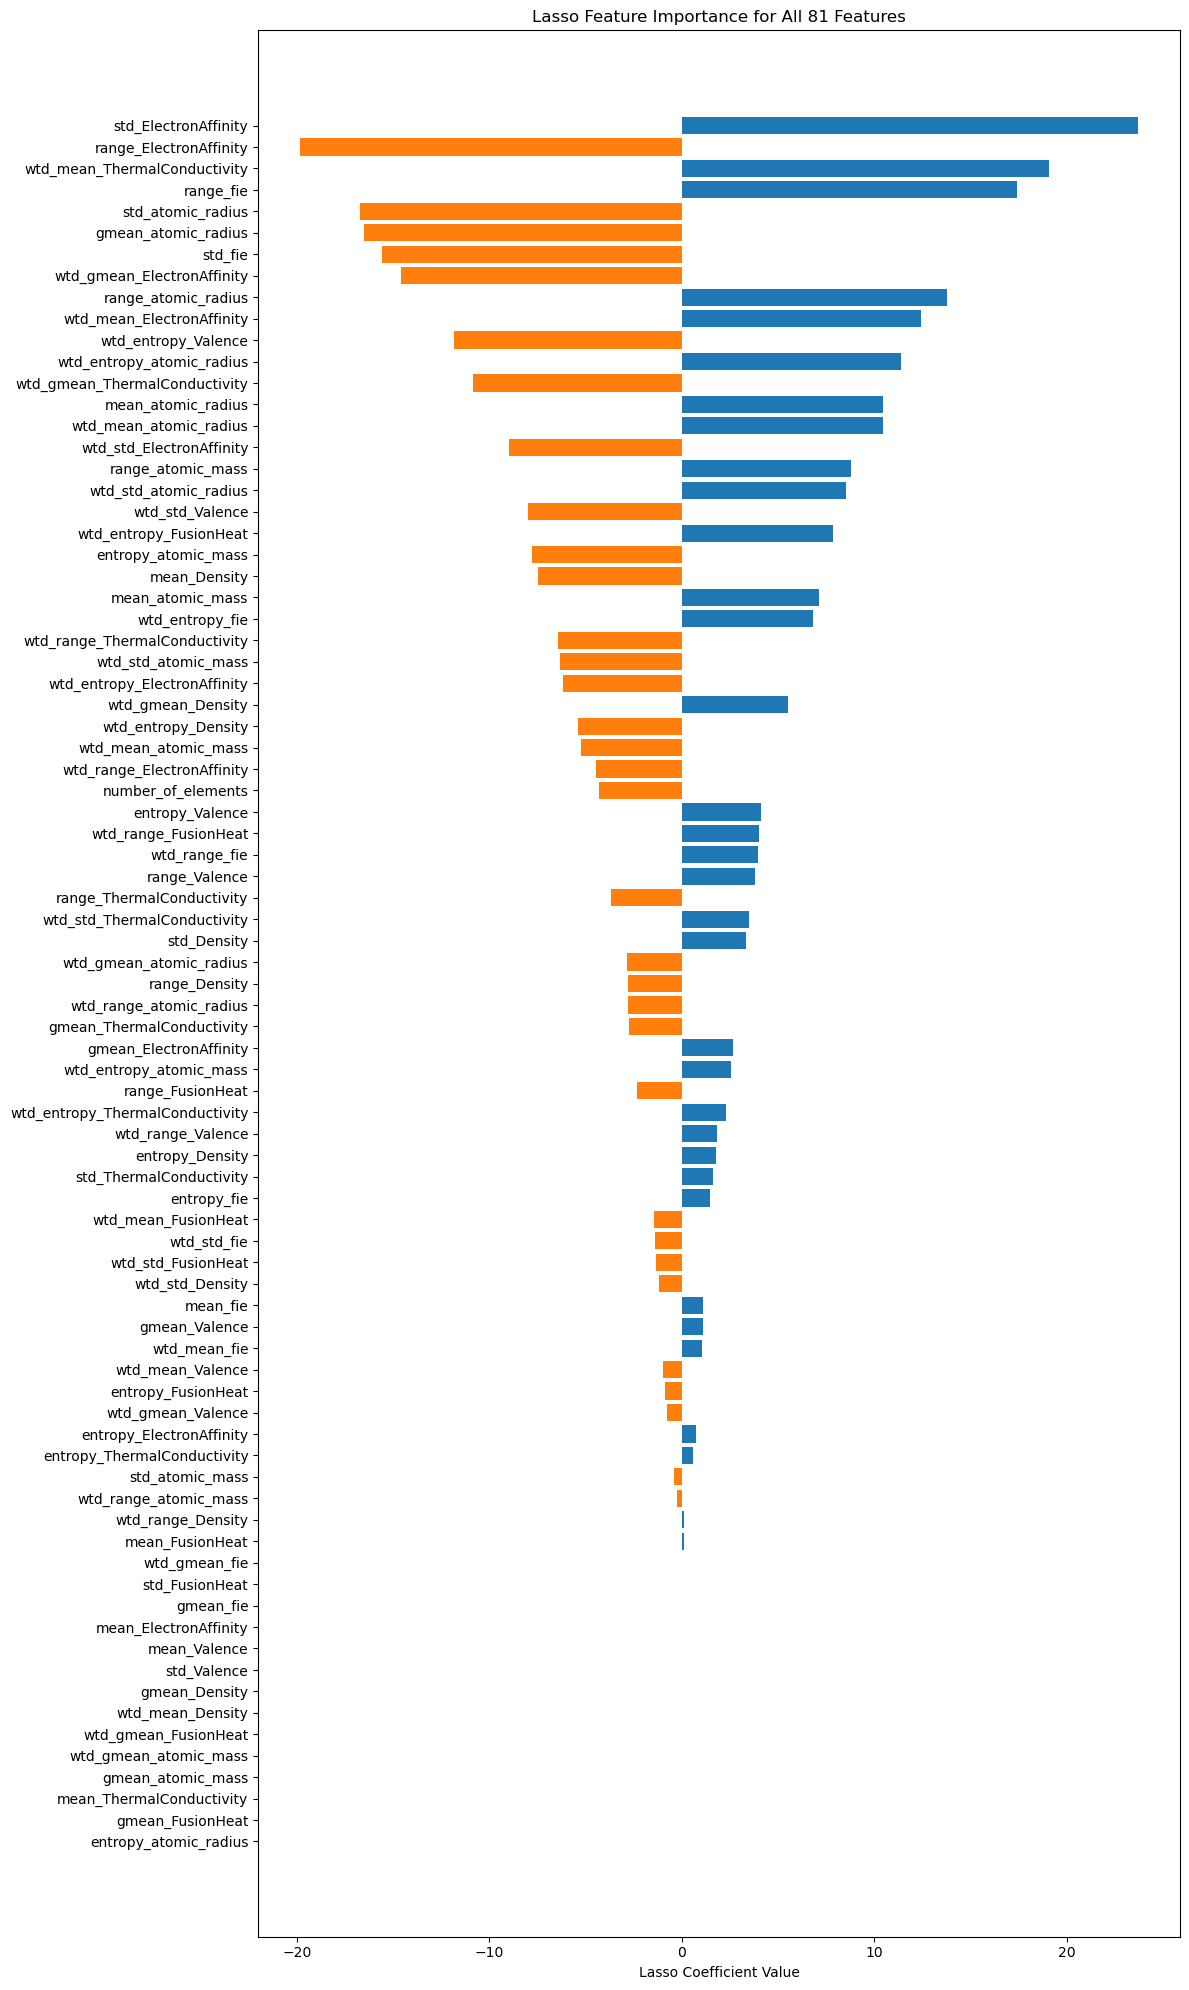

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

# Load dataset
path = r"C:\Users\pchtc\.cache\kagglehub\datasets\tunguz\superconductivty-data-data-set\versions\1\train.csv"
df = pd.read_csv(path)

# Separate features and target
X = df.drop('critical_temp', axis=1)
y = df['critical_temp']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Lasso with cross-validation
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.6f}")

# Create DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

# Sort by coefficient magnitude
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=True)

# Plot all 81 features
plt.figure(figsize=(12, 20))
colors = ['#1f77b4' if c > 0 else '#ff7f0e' for c in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)

plt.xlabel("Lasso Coefficient Value")
plt.title("Lasso Feature Importance for All 81 Features")
plt.tight_layout()
plt.show()
print("\nTop 15 Features by Absolute Coefficient:")
print(coef_df_sorted.tail(15))

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = lasso.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R²: {r2:.3f}")
print(f"MSE: {mse:.3f}")


R²: 0.732
MSE: 309.060


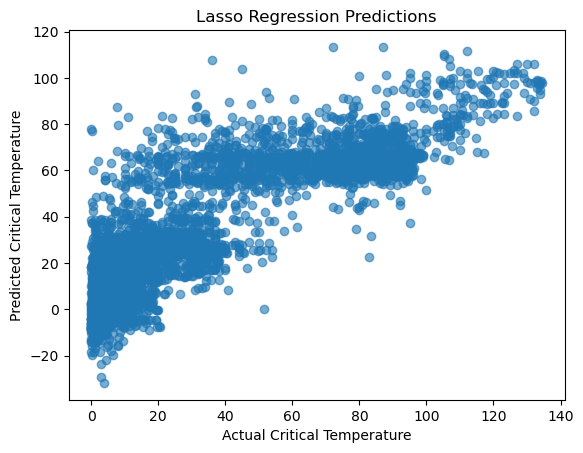

In [17]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Lasso Regression Predictions")
plt.show()


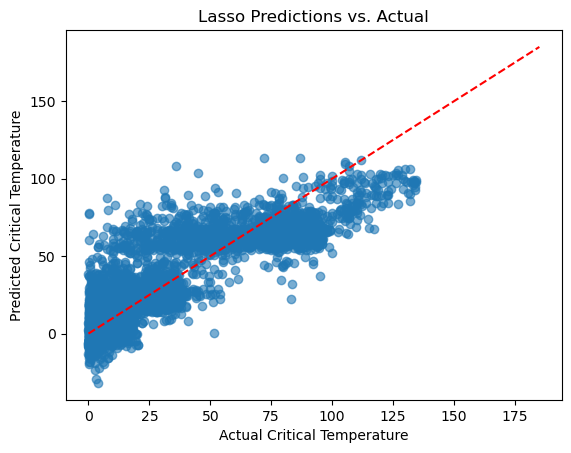

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # y=x reference line
plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Lasso Predictions vs. Actual")
plt.show()


In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lasso_poly = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_poly.fit(X_train_poly, y_train)

y_pred_poly = lasso_poly.predict(X_test_poly)

print("R² (Lasso + Poly):", r2_score(y_test, y_pred_poly))
print("MSE (Lasso + Poly):", mean_squared_error(y_test, y_pred_poly))


R² (Lasso + Poly): 0.8339222649880597
MSE (Lasso + Poly): 191.16883460501344


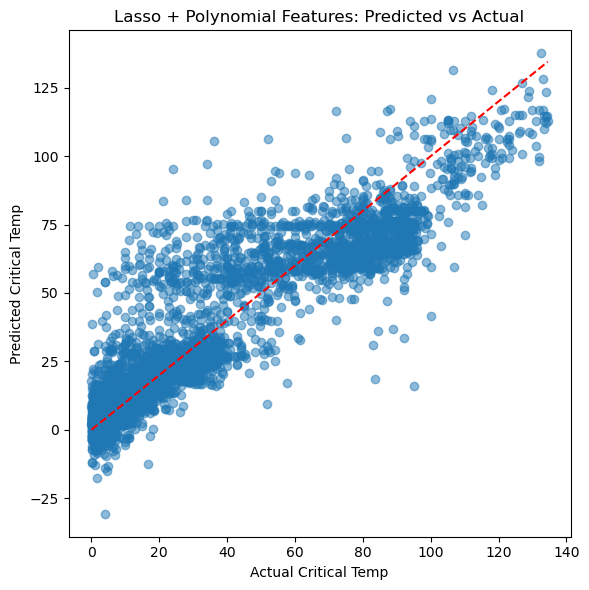

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.xlabel("Actual Critical Temp")
plt.ylabel("Predicted Critical Temp")
plt.title("Lasso + Polynomial Features: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()


c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.662e+06, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.388e+06, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\pchtc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.252e+06, toleranc

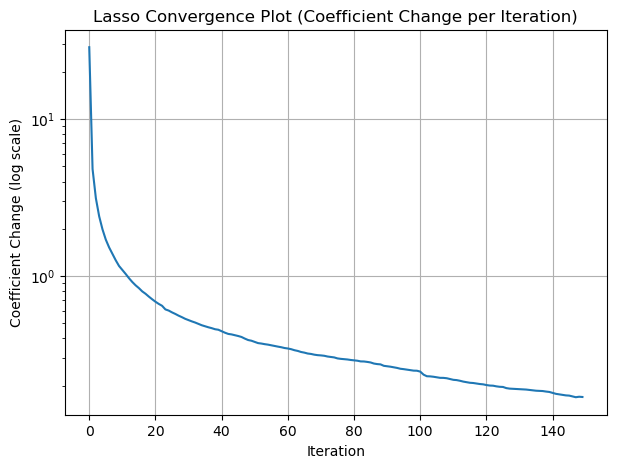

In [19]:
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

# Use the alpha found by LassoCV
alpha = lasso_poly.alpha_

lasso_iter = Lasso(alpha=alpha, warm_start=True, max_iter=1)

coef_path = []
n_iters = 150   # number of iterations you want to simulate

coef_prev = np.zeros(X_train_poly.shape[1])

for i in range(n_iters):
    lasso_iter.fit(X_train_poly, y_train)
    coef_curr = lasso_iter.coef_
    
    # Track change in coefficients (L2 norm)
    diff = np.linalg.norm(coef_curr - coef_prev)
    coef_path.append(diff)
    
    coef_prev = coef_curr.copy()
    
    # Update warm start for next iteration
    lasso_iter.coef_ = coef_curr.copy()

# ---- Plot convergence ----
plt.figure(figsize=(7,5))
plt.plot(coef_path)
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Coefficient Change (log scale)")
plt.title("Lasso Convergence Plot (Coefficient Change per Iteration)")
plt.grid(True)
plt.show()
